In [11]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
gc.collect()
torch.cuda.empty_cache()

device = torch.device('cuda')
print("GPUs available:", torch.cuda.device_count())

GPUs available: 2


In [12]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class PreCroppedPatchDataset(Dataset):
    def __init__(self, split_dir, mask_base_dir):
        self.img_dir = split_dir
        self.fs_dir = os.path.join(mask_base_dir, 'fastsam')
        self.gt_dir = os.path.join(mask_base_dir, 'gt')
        self.img_files = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fs_mask = cv2.imread(os.path.join(self.fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.imread(os.path.join(self.gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        
        img_tensor = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        fs_tensor = torch.from_numpy((fs_mask > 127).astype(np.float32)).unsqueeze(0)
        gt_tensor = torch.from_numpy((gt_mask > 127).astype(np.float32)).unsqueeze(0)
        
        return img_tensor, fs_tensor, gt_tensor

In [13]:
# ==========================================
# 1. MODEL & LOSS CLASSES
# ==========================================

class ResBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

# MODEL 1: The Puller (Deep & Narrow, snaps to edges)
class BoundaryPuller(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.mask_stem = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pre_loop = nn.Sequential(
            nn.Conv2d(24, 24, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.looper = nn.Sequential(
            ResBlock(24, dilation=1),
            ResBlock(24, dilation=2),
            ResBlock(24, dilation=4),
            nn.Conv2d(24, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, init_mask, iters=3):
        img_feats = self.img_stem(img)
        curr_logits = (init_mask - 0.5) * 2.0 

        for _ in range(iters):
            curr_mask = torch.sigmoid(curr_logits)
            mask_feats = self.mask_stem(curr_mask)
            x = torch.cat([img_feats, mask_feats], dim=1)
            x = self.pre_loop(x)
            delta = self.looper(x)
            curr_logits = curr_logits + delta
            
        return torch.sigmoid(curr_logits)


# MODEL 2: The Smoother (Shallow, just irons out the jaggies)
class BoundarySmoother(nn.Module):
    def __init__(self):
        super().__init__()
        # Takes Image (3) + Mask (1) = 4 channels
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        logits = self.net(x)
        return torch.sigmoid(logits)


# LOSS 1: Just the soft boundary BCE to pull the edge perfectly
class PullerLoss(nn.Module):
    def __init__(self, blur_kernel=11):
        super().__init__()
        self.blur_kernel = blur_kernel

    def forward(self, pred, target):
        dilated = F.max_pool2d(target, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-target, kernel_size=3, stride=1, padding=1)
        gt_boundary = dilated - eroded
        
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        weight_map = 0.2 + (4.8 * (soft_glow / (soft_glow.max() + 1e-6)))
        
        bce = F.binary_cross_entropy(pred, target, reduction='none')
        return (bce * weight_map).mean()


# LOSS 2: BCE + TV Loss (Now TV loss is safe because M1 already pulled the edge)
class SmootherLoss(nn.Module):
    def __init__(self, tv_weight=1.0):
        super().__init__()
        self.tv_weight = tv_weight

    def forward(self, pred, target):
        bce = F.binary_cross_entropy(pred, target)
        
        tv_x = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
        tv_y = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
        tv_loss = tv_x.mean() + tv_y.mean()
        
        return bce + (self.tv_weight * tv_loss)

In [14]:
# ==========================================
# 2. DATASET LOAD
# ==========================================
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"
train_dataset = PreCroppedPatchDataset(
    os.path.join(base_path, "train"),
    os.path.join(base_path, "train_masks")
)

train_loader = DataLoader(
    train_dataset, batch_size=96, shuffle=True, num_workers=2, pin_memory=True
)

In [15]:
# ==========================================
# 3. TRAIN STAGE 1 (THE PULLER)
# ==========================================
print("\n--- STARTING STAGE 1: TRAINING BOUNDARY PULLER ---")
model1 = BoundaryPuller()
if torch.cuda.device_count() > 1:
    model1 = nn.DataParallel(model1)
model1 = model1.to(device)

criterion1 = PullerLoss(blur_kernel=11)
optimizer1 = optim.Adam(model1.parameters(), lr=1e-3)

epochs1 = 10
for epoch in range(epochs1):
    model1.train()
    total_loss = 0
    for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
        imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
        optimizer1.zero_grad()
        iters = random.randint(2, 5)
        m1_preds = model1(imgs, fs_masks, iters)
        
        loss = criterion1(m1_preds, gt_masks)
        loss.backward()
        optimizer1.step()
        total_loss += loss.item()

    print(f"M1 Epoch {epoch} Avg Loss: {total_loss / len(train_loader):.4f}")

# Save Model 1
if isinstance(model1, nn.DataParallel):
    torch.save(model1.module.state_dict(), "/kaggle/working/puller_final.pth")
else:
    torch.save(model1.state_dict(), "/kaggle/working/puller_final.pth")


--- STARTING STAGE 1: TRAINING BOUNDARY PULLER ---
M1 Epoch 0 Avg Loss: 0.0923
M1 Epoch 1 Avg Loss: 0.0828
M1 Epoch 2 Avg Loss: 0.0751
M1 Epoch 3 Avg Loss: 0.0813
M1 Epoch 4 Avg Loss: 0.0740
M1 Epoch 5 Avg Loss: 0.0714
M1 Epoch 6 Avg Loss: 0.0703
M1 Epoch 7 Avg Loss: 0.0664
M1 Epoch 8 Avg Loss: 0.0656
M1 Epoch 9 Avg Loss: 0.0664


In [16]:
# ==========================================
# 4. CLEAR GPU BEFORE STAGE 2
# ==========================================
print("\nClearing GPU Memory for Stage 2...")
model1.eval() # Freeze M1 for Stage 2
optimizer1 = None
criterion1 = None
gc.collect()
torch.cuda.empty_cache()


Clearing GPU Memory for Stage 2...


In [19]:
# ==========================================
# 5. TRAIN STAGE 2 (THE SMOOTHER)
# ==========================================
print("\n--- STARTING STAGE 2: TRAINING BOUNDARY SMOOTHER ---")
model2 = BoundarySmoother()
if torch.cuda.device_count() > 1:
    model2 = nn.DataParallel(model2)
model2 = model2.to(device)

criterion2 = SmootherLoss(tv_weight=1.0)
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)

epochs2 = 10
for epoch in range(epochs2):
    model2.train()
    total_loss = 0
    for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
        imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
        # Get M1 predictions without tracking gradients to save memory
        with torch.no_grad():
            iters = 4 # Fixed iters for inference
            m1_preds = model1(imgs, fs_masks, iters)
            # Threshold it so M2 sees a solid mask, not soft probabilities
            m1_bin = (m1_preds > 0.5).float()
            
        optimizer2.zero_grad()
        m2_preds = model2(imgs, m1_bin)
        
        loss = criterion2(m2_preds, gt_masks)
        loss.backward()
        optimizer2.step()
        total_loss += loss.item()

    print(f"M2 Epoch {epoch} Avg Loss: {total_loss / len(train_loader):.4f}")

# Save Model 2
if isinstance(model2, nn.DataParallel):
    torch.save(model2.module.state_dict(), "/kaggle/working/smoother_final.pth")
else:
    torch.save(model2.state_dict(), "/kaggle/working/smoother_final.pth")

print("\nBoth models trained and saved!")


--- STARTING STAGE 2: TRAINING BOUNDARY SMOOTHER ---


KeyboardInterrupt: 

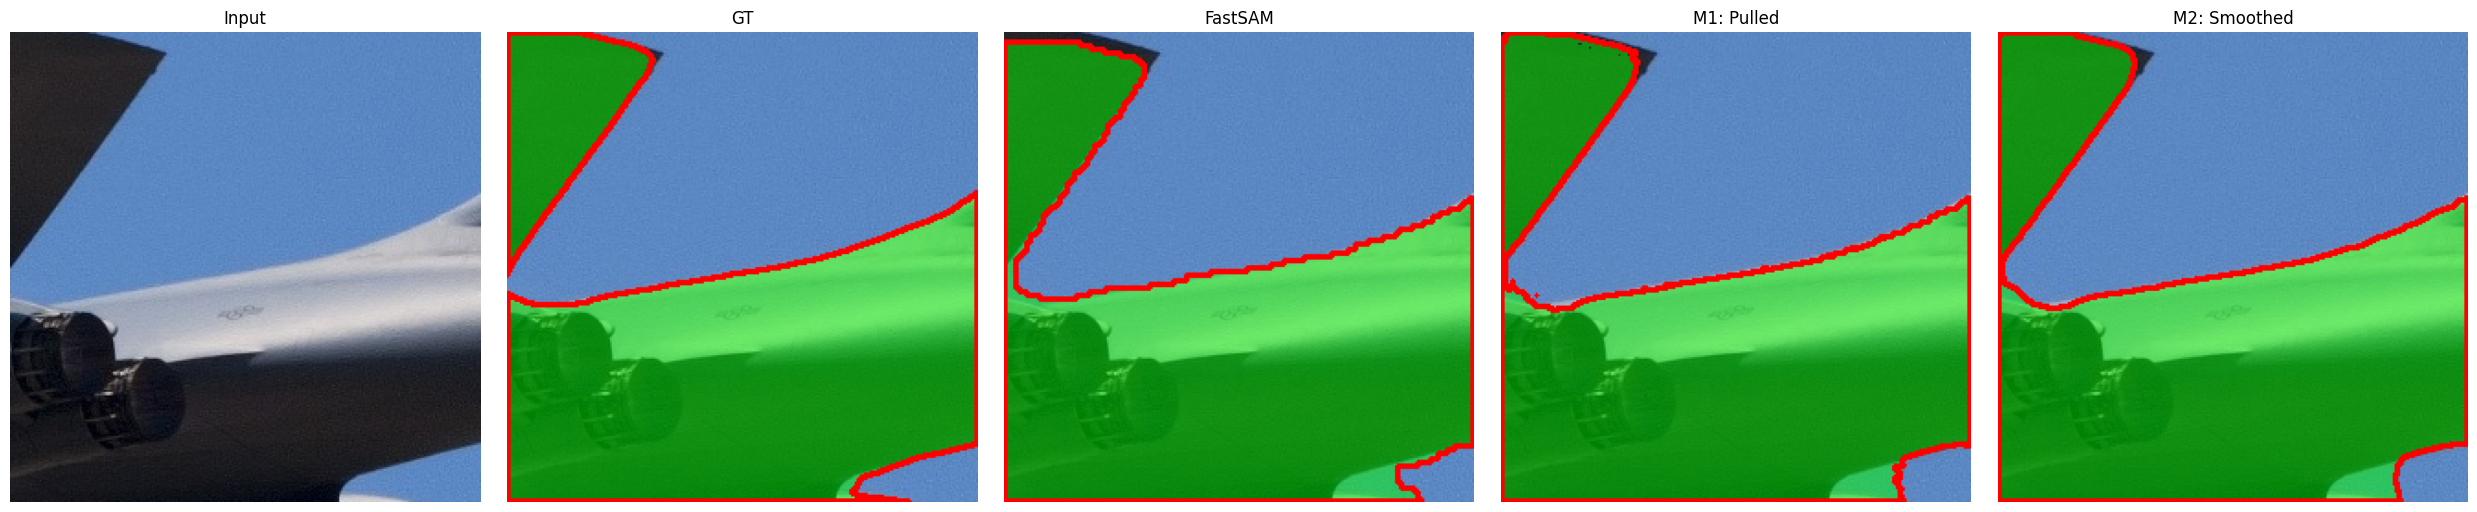

In [73]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

gc.collect()
torch.cuda.empty_cache()

# ===== TEST / VISUALIZATION =====

def create_overlay(img_base, mask, mask_color=(0, 255, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask_bin[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    return overlay


device = torch.device('cuda:0')

# ===== LOAD MODELS =====
# Ensure BoundaryPuller and BoundarySmoother are defined in the cells above
model1 = BoundaryPuller().to(device)
model1.load_state_dict(torch.load("/kaggle/working/puller_final.pth", map_location=device))
model1.eval()

model2 = BoundarySmoother().to(device)
model2.load_state_dict(torch.load("/kaggle/working/smoother_final.pth", map_location=device))
model2.eval()


# ===== PATHS =====
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"

test_img_dir = os.path.join(base_path, "val")
test_fs_dir = os.path.join(base_path, "val_masks/fastsam")
test_gt_dir = os.path.join(base_path, "val_masks/gt")


# ===== RANDOM SAMPLE =====
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
img_name = random.choice(test_imgs)
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(os.path.join(test_gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)
gt_bin = (gt_mask > 127).astype(np.uint8)


# ===== INFERENCE =====
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
            .permute(2, 0, 1).unsqueeze(0).to(device)

fs_t = torch.from_numpy(fs_bin.astype(np.float32))\
           .unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    # Stage 1: Pull the boundary to the actual object edge
    m1_pred_t = model1(img_t, fs_t, iters=4)
    # Threshold it to a hard binary mask for M2
    m1_bin_t = (m1_pred_t > 0.5).float()
    
    # Stage 2: Iron out the jaggies using the TV-trained model
    m2_pred_t = model2(img_t, m1_bin_t)
    
    m1_out = m1_pred_t.squeeze().cpu().numpy()
    m2_out = m2_pred_t.squeeze().cpu().numpy()


# ===== POST-PROCESS =====
m1_bin_np = (m1_out > 0.5).astype(np.uint8)
m2_bin_np = (m2_out > 0.5).astype(np.uint8)


# ===== VISUALIZATION =====
# Expanding to 5 columns so we can see the exact difference Model 2 makes
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(img_rgb); axes[0].set_title("Input")
axes[1].imshow(create_overlay(img_rgb, gt_bin)); axes[1].set_title("GT")
axes[2].imshow(create_overlay(img_rgb, fs_bin)); axes[2].set_title("FastSAM")
axes[3].imshow(create_overlay(img_rgb, m1_bin_np)); axes[3].set_title("M1: Pulled")
axes[4].imshow(create_overlay(img_rgb, m2_bin_np)); axes[4].set_title("M2: Smoothed")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Visible new problem: rectangularish obj pred by fastsam is remaining rectangularish like the head, and not smoothened and pulled to become circular like GT.